In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Setting the style for visualizations
sns.set_theme(style="whitegrid")

# Load the CSV
df = pd.read_csv("../data/Tanzania/tanzania.csv")

# Add Country column
df["Country"] = "Tanzania"

# Convert YEAR and DOY to datetime
# Format %Y%j handles Year + Day of Year (1-366)
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column
df["Month"] = df["Date"].dt.month

#Printing the size of the data and viewing the top 5 rows of the data
print("Size of the dataset for Tanzania is", df.shape)
df.head()


Size of the dataset for Tanzania is (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [2]:
# 1. Replace NASA sentinel values
df.replace(-999, np.nan, inplace=True)

# 2. Handle Duplicates and print them if there are any
duplicates = df.duplicated().sum()
print(f"Total Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# 3. Missing Value Report
null_report = df.isna().sum()
null_percent = (null_report / len(df)) * 100
print("Percentage of missing values per column:")
print(null_percent) 

# Run summary statistics for all numeric columns
df.describe()

Total Duplicate rows found: 0
Percentage of missing values per column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


Data Quality Interpretation:

* Missing Values: After replacing NASA sentinel values (-999), the dataset contains 0% missing values across all columns. This indicates a high-quality, coninuous record for the Tanzania climate data.
* Duplicates: No duplicate rows were detected, ensuring that time-series observations are unique.
* Summary Stats: The average temprature is approximately 26.802422°C, with a maximum of 29.163493°C

In [3]:
from scipy import stats
import numpy as np

# Columns to check for outliers
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores (number of standard deviations away from the mean)
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any column has a Z-score > 3
outlier_rows = (z_scores > 3).any(axis=1)
outlier_count = outlier_rows.sum()

print(f"Total rows flagged as outliers (|Z| > 3): {outlier_count}")

# Display outlier counts per specific column
outliers_per_col = (z_scores > 3).sum()
print("\nOutliers detected per column:", outliers_per_col)
print("")


## The following code displays the first 20 rows that contain
## atleast one outlier, highlighing the extreme values.

# Convert the mask to a DataFrame so we can use Pandas tools
outlier_mask = (z_scores > 3)
outlier_mask_df = pd.DataFrame(outlier_mask, columns=cols_to_check)

# This creates a summary showing which columns were outliers for the flagged rows
# We filter it to only show rows where at least one value is True
flagged_only = outlier_mask_df[outlier_mask_df.any(axis=1)]

print(f"Showing the 'culprit' columns for the first 20 outliers:")
for index, row in flagged_only.head(20).iterrows():
    # Get the column names where the value is True
    flagged_cols = row[row == True].index.tolist()
    
    # Get the date from the original dataframe using the index
    obs_date = df.loc[index, 'Date'].date()
    
    print(f"Row {index} (Date: {obs_date}): Outliers in {flagged_cols}")

Total rows flagged as outliers (|Z| > 3): 97

Outliers detected per column: 102

Showing the 'culprit' columns for the first 20 outliers:
Row 78 (Date: 2015-03-20): Outliers in ['PRECTOTCORR']
Row 112 (Date: 2015-04-23): Outliers in ['PRECTOTCORR']
Row 123 (Date: 2015-05-04): Outliers in ['PRECTOTCORR']
Row 124 (Date: 2015-05-05): Outliers in ['PRECTOTCORR']
Row 126 (Date: 2015-05-07): Outliers in ['PRECTOTCORR']
Row 127 (Date: 2015-05-08): Outliers in ['PRECTOTCORR']
Row 214 (Date: 2015-08-03): Outliers in ['WS2M']
Row 256 (Date: 2015-09-14): Outliers in ['WS2M']
Row 478 (Date: 2016-04-23): Outliers in ['PRECTOTCORR']
Row 481 (Date: 2016-04-26): Outliers in ['PRECTOTCORR']
Row 482 (Date: 2016-04-27): Outliers in ['PRECTOTCORR']
Row 801 (Date: 2017-03-12): Outliers in ['PRECTOTCORR']
Row 825 (Date: 2017-04-05): Outliers in ['PRECTOTCORR']
Row 836 (Date: 2017-04-16): Outliers in ['PRECTOTCORR']
Row 838 (Date: 2017-04-18): Outliers in ['PRECTOTCORR']
Row 839 (Date: 2017-04-19): Outliers 

Outlier Analysis & Handling Decision:

* Detection Methodology: Using the Z-score method (|Z|>3), we identified 97 rows containing outliers. A closer inspection of these outliers reveals clear seasonal patterns.
* Key Observations from Flagged Data:

    
* Decision: I chose to RETAIN all 97 outlier rows.
* Reasoning: Climate change analysis in Africa is largely focused on the frequency and intensity of extreme events. The clustered nature of these outliers provides essential data on weather volatitlity. Dropping these points would lead to an understimation of the climate risks that COP32 aims to address.

In [4]:
# Exporting the cleaned DataFrame
import os

# 1. Ensure the data directory exists (just in case)
os.makedirs("../data", exist_ok=True)

# 2. Define the filename dynamically
clean_filename = f"../data/Tanzania/tanzania_clean.csv"

# 3. Export to CSV
# index=False is crucial so you don't add an extra 'Unnamed: 0' column
df.to_csv(clean_filename, index=False)

print(f"Successfully exported cleaned data to: {clean_filename}")

Successfully exported cleaned data to: ../data/Tanzania/tanzania_clean.csv


Data Export Note: The cleaned dataset has been exported to data/Tanzania/tanzania_clean.csv. This file is explicitly excluded from version control via .gitignore to prevent data leakage while maintaining a reproducible cleaning pipeline.

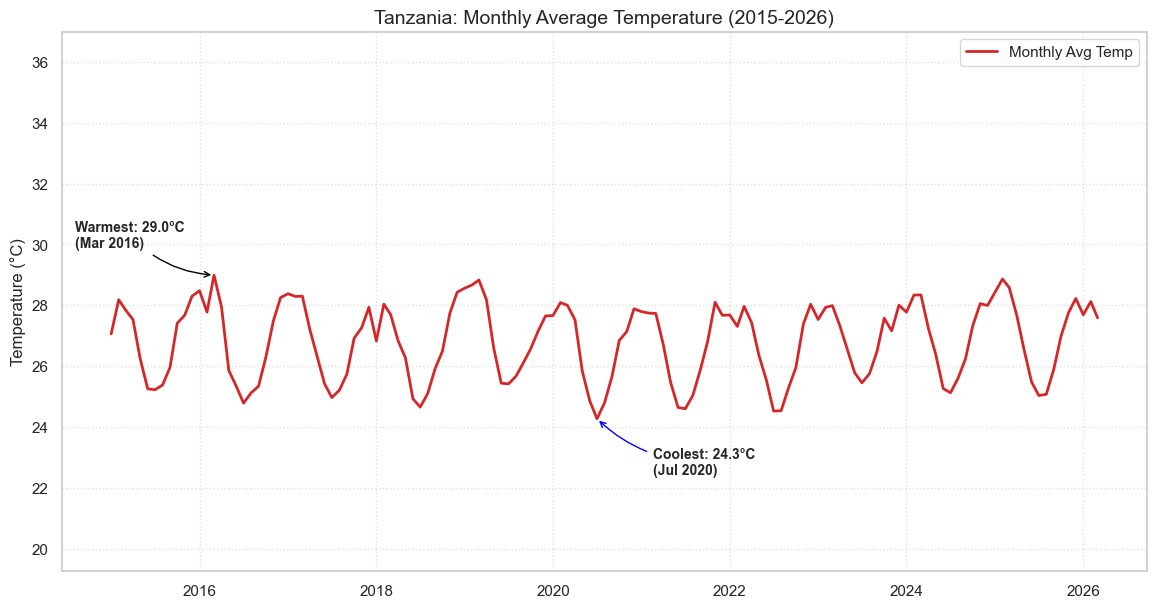

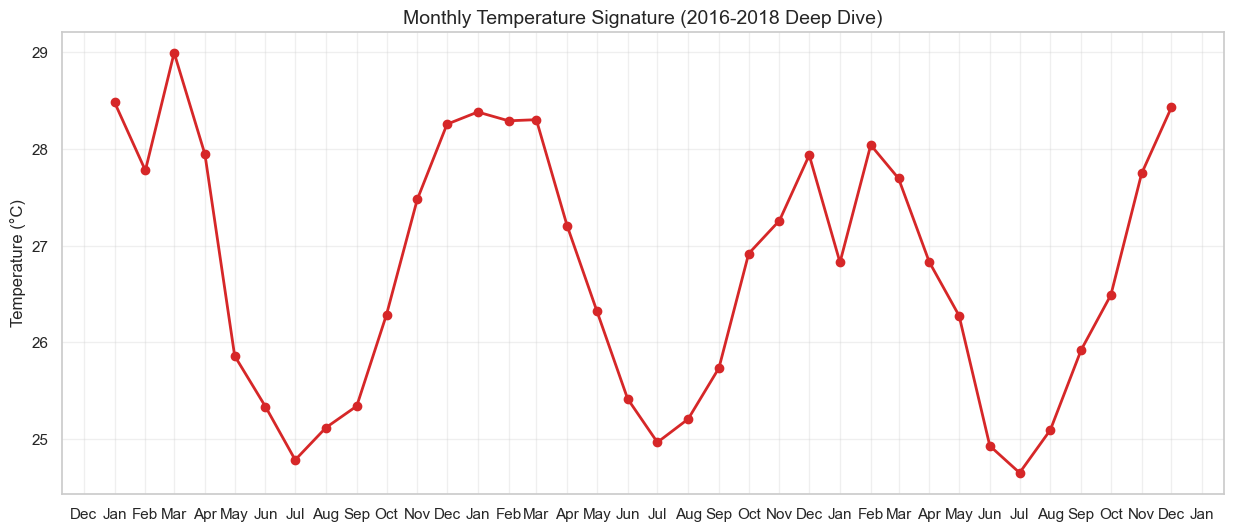

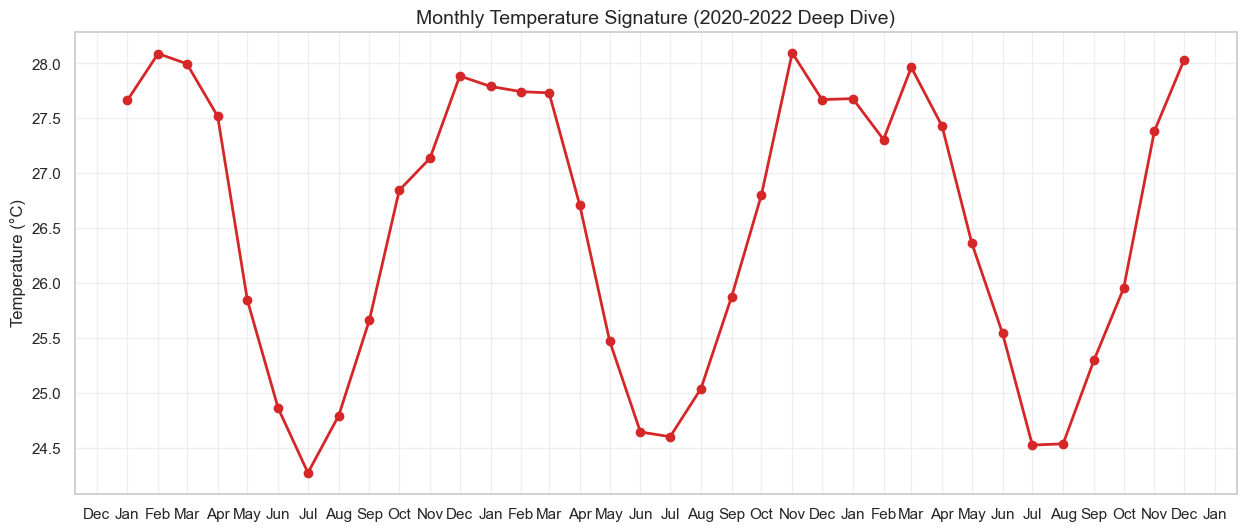

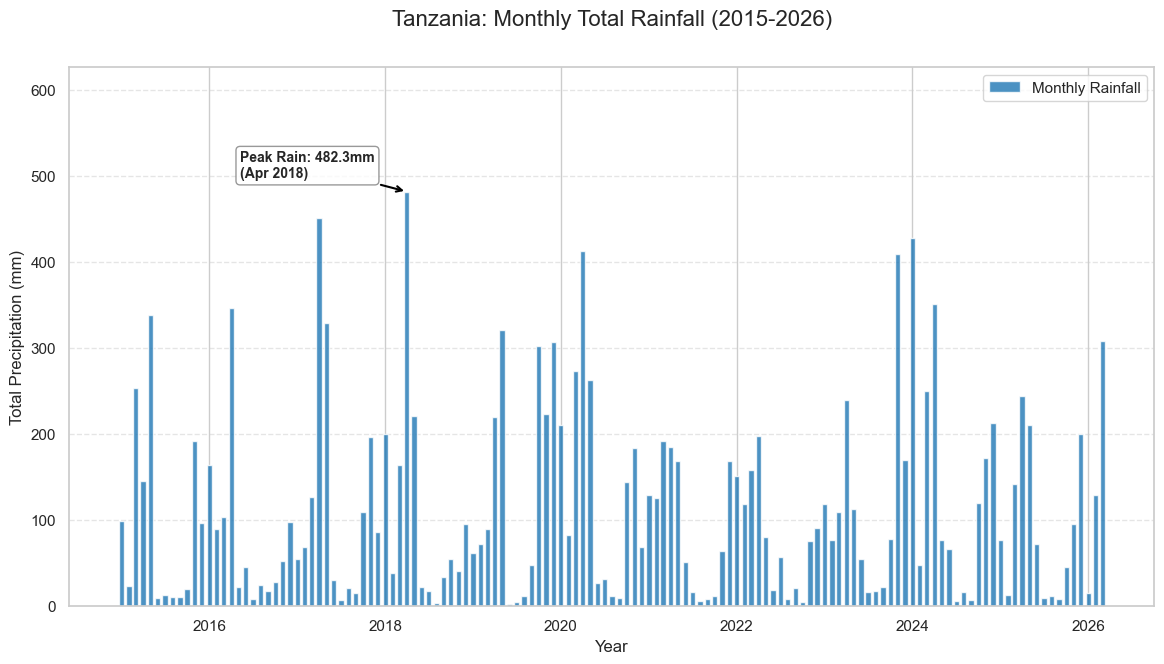

In [5]:
## Temperature Line Chart (T2M) with annotations
import matplotlib.pyplot as plt
import pandas as pd

# Ensure Date is datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
temp_df = df.set_index('Date')['T2M'].resample('MS').mean()

# Find warmest and coolest for annotation
warmest_date = temp_df.idxmax()
warmest_val = temp_df.max()
coolest_date = temp_df.idxmin()
coolest_val = temp_df.min()

plt.figure(figsize=(14, 7))
plt.plot(temp_df.index, temp_df, color='#d62728', linewidth=2, label='Monthly Avg Temp')

# Annotations
plt.annotate(f'Warmest: {warmest_val:.1f}°C\n({warmest_date.strftime("%b %Y")})', 
             xy=(warmest_date, warmest_val), xytext=(-100, 20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black', connectionstyle="arc3,rad=.2"), fontsize=10, fontweight='bold')

plt.annotate(f'Coolest: {coolest_val:.1f}°C\n({coolest_date.strftime("%b %Y")})', 
             xy=(coolest_date, coolest_val), xytext=(40, -40),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='blue', connectionstyle="arc3,rad=-.2"), fontsize=10, fontweight='bold')

plt.ylim(temp_df.min() - 5, temp_df.max() + 8)
plt.title('Tanzania: Monthly Average Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

import matplotlib.dates as mdates

# Filter data for a 2-year window to see months clearly for better analysis
# 1) 2016 - 2018

plt.figure(figsize=(15, 6))

zoom_df = temp_df['2016':'2018'] 

plt.plot(zoom_df.index, zoom_df, marker='o', color='#d62728', linewidth=2)

# This is the magic part: Force month labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Mark every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Show 'Jan', 'Feb', etc.

# Add the Year below the months
plt.gca().xaxis.set_minor_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_formatter(mdates.DateFormatter('\n\n%Y'))

plt.title('Monthly Temperature Signature (2016-2018 Deep Dive)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# 2) 2020 - 2022

plt.figure(figsize=(15, 6))

zoom_df = temp_df['2020':'2022'] 

plt.plot(zoom_df.index, zoom_df, marker='o', color='#d62728', linewidth=2)

# This is the magic part: Force month labels
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Mark every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b')) # Show 'Jan', 'Feb', etc.

# Add the Year below the months
plt.gca().xaxis.set_minor_locator(mdates.YearLocator())
plt.gca().xaxis.set_minor_formatter(mdates.DateFormatter('\n\n%Y'))

plt.title('Monthly Temperature Signature (2020-2022 Deep Dive)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

## Rainfall Bar Chart (PRECTOTCORR)

# Calculate Monthly Total Rainfall
rain_df = df.set_index('Date')['PRECTOTCORR'].resample('MS').sum()

# Identify peak month
peak_rain_date = rain_df.idxmax()
peak_rain_val = rain_df.max()

plt.figure(figsize=(14, 7))
plt.bar(rain_df.index, rain_df, width=22, color='#1f77b4', alpha=0.8, label='Monthly Rainfall')

# Annotate Peak
plt.annotate(f'Peak Rain: {peak_rain_val:.1f}mm\n({peak_rain_date.strftime("%b %Y")})', 
             xy=(peak_rain_date, peak_rain_val), xytext=(-120, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black', lw=1.5), fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.ylim(0, rain_df.max()*1.3)
plt.title('Tanzania: Monthly Total Rainfall (2015-2026)', fontsize=16, pad=30)
plt.ylabel('Total Precipitation (mm)')
plt.xlabel('Year')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Analysis of Climate Trends (2015-2026):

* Seasonal Temperature and Rainfall Dynamics

    *



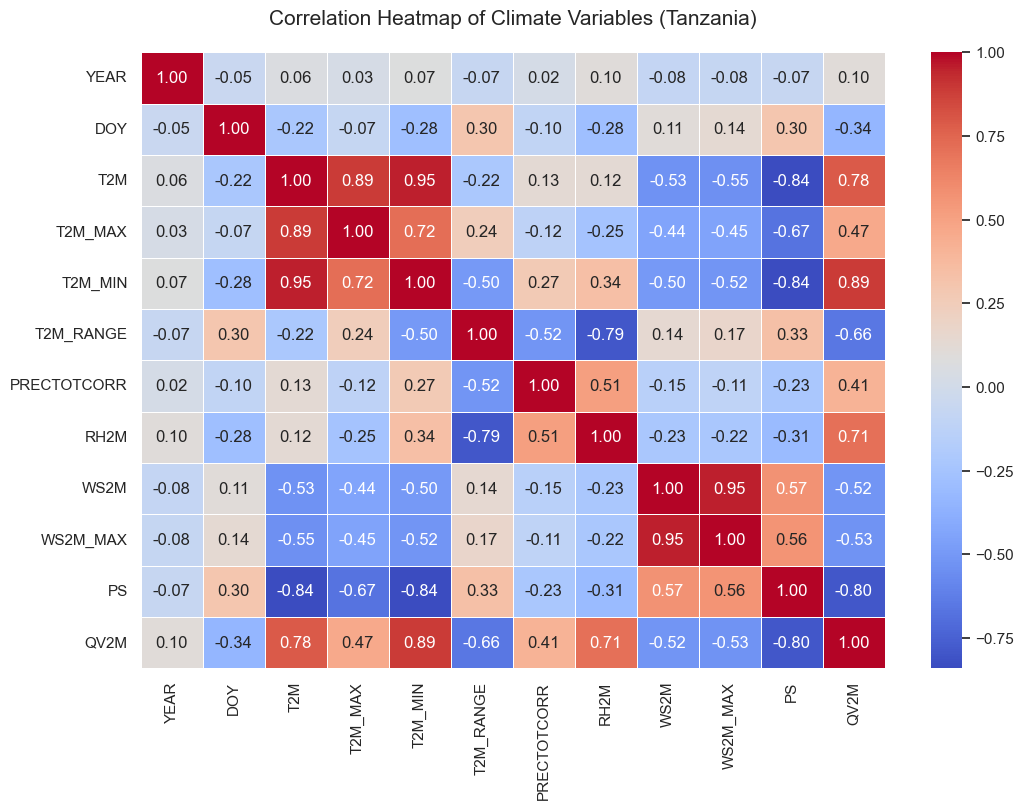

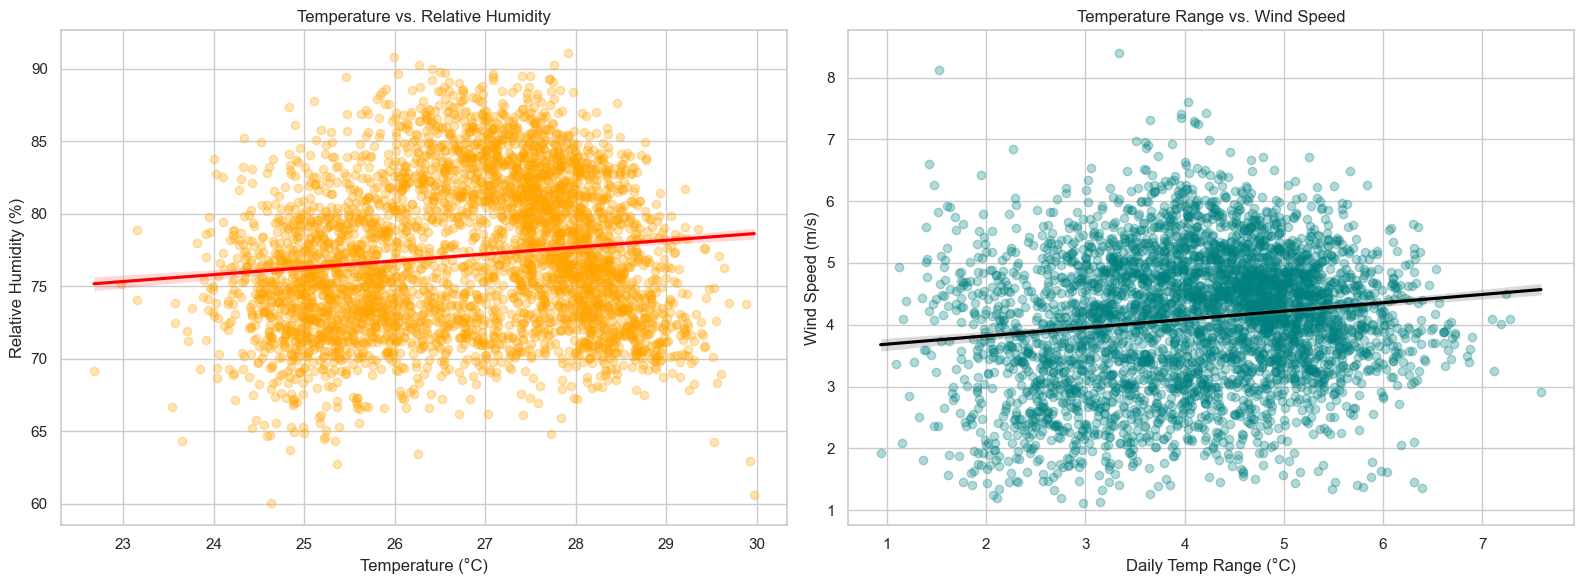

In [6]:
## Correlation Heatmap

import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Climate Variables (Tanzania)', fontsize=15, pad=20)
plt.show()

## Scatter Plots

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T2M vs RH2M
sns.regplot(data=df, x='T2M', y='RH2M', ax=ax1, 
            scatter_kws={'alpha':0.3, 'color':'orange'}, line_kws={'color':'red'})
ax1.set_title('Temperature vs. Relative Humidity')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: T2M_RANGE vs WS2M
sns.regplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'black'})
ax2.set_title('Temperature Range vs. Wind Speed')
ax2.set_xlabel('Daily Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

Interpreting the Top 3 Correlations

1. 

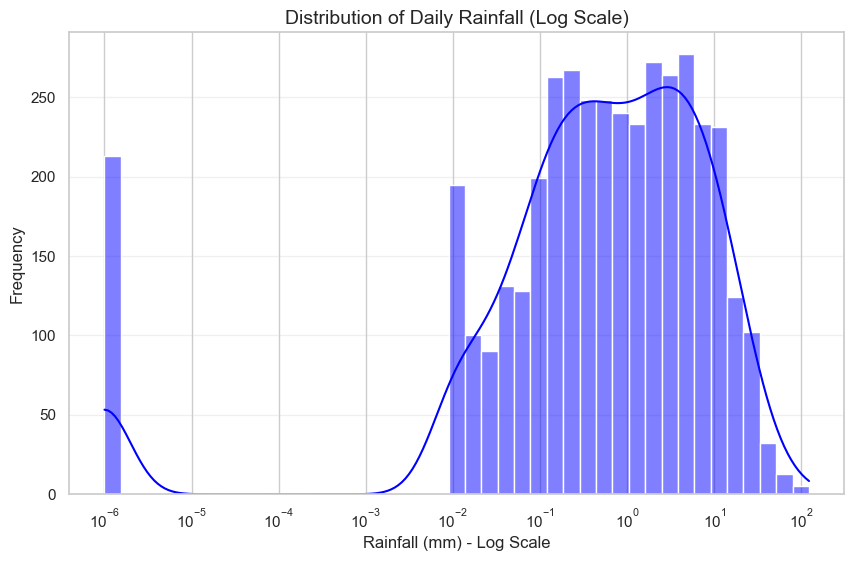

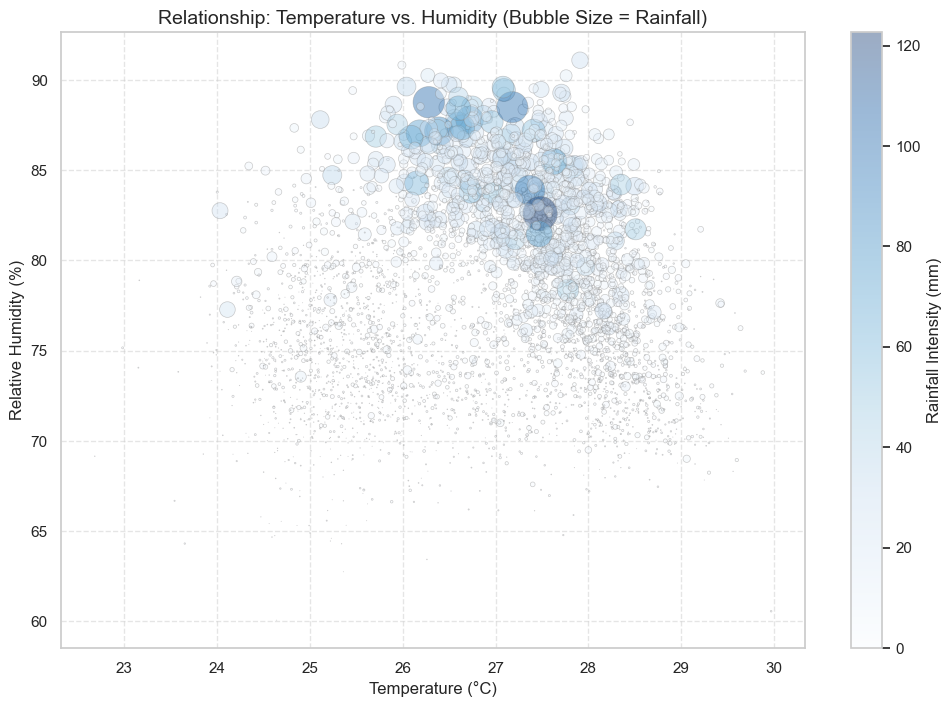

In [7]:
## Histogtam of Rainfall (PRECTOTCORR)

plt.figure(figsize=(10, 6))

# We add a tiny constant (1e-6) to avoid log(0) errors for dry days
sns.histplot(df['PRECTOTCORR'] + 1e-6, kde=True, color='blue', log_scale=True)

plt.title('Distribution of Daily Rainfall (Log Scale)', fontsize=14)
plt.xlabel('Rainfall (mm) - Log Scale')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Bubble Chart: T2M vs. RH2M (Size=Rain)

plt.figure(figsize=(12, 8))

# Create the scatter/bubble plot
scatter = plt.scatter(df['T2M'], df['RH2M'], 
                      s=df['PRECTOTCORR']*5, # Scaling factor to make bubbles visible
                      alpha=0.4, 
                      c=df['PRECTOTCORR'], # Color also mapped to rain for clarity
                      cmap='Blues', 
                      edgecolors='grey', 
                      linewidth=0.5)

# Add a colorbar to show rain intensity
cbar = plt.colorbar(scatter)
cbar.set_label('Rainfall Intensity (mm)')

plt.title('Relationship: Temperature vs. Humidity (Bubble Size = Rainfall)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

* Rainfall Distribution & Variable Interaction

    * 